In [1]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import gysela_utilities as utils;

# Styling.
plt.style.use("ggplot");

In [9]:
from scipy import signal;

In [2]:
# Test inputs - delete when done!
time_step = reader.fetch_data_from_h5("/home/thur0011/GYSELA/simulations_raw/fresh_batch_7.0/DN_DAYCASE_DELTASCAN_255X512_Q3.5_-0.3/sp0/Phi2D/Phi2D_d00000.h5")["deltat"].values;
data_arrays = reader.compile_data_from_directory("Phirth_n0", "/home/thur0011/GYSELA/simulations_raw/fresh_batch_7.0/DN_DAYCASE_DELTASCAN_255X512_Q3.5_-0.3/sp0/Phi2D");

<>:15: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1147583/3132965005.py:15: SyntaxWarning: invalid escape sequence '\d'
  plt.title("GAM damping & RH residual relaxation (q = 3.5, $\delta$ = -0.3)");


13.074912891986065


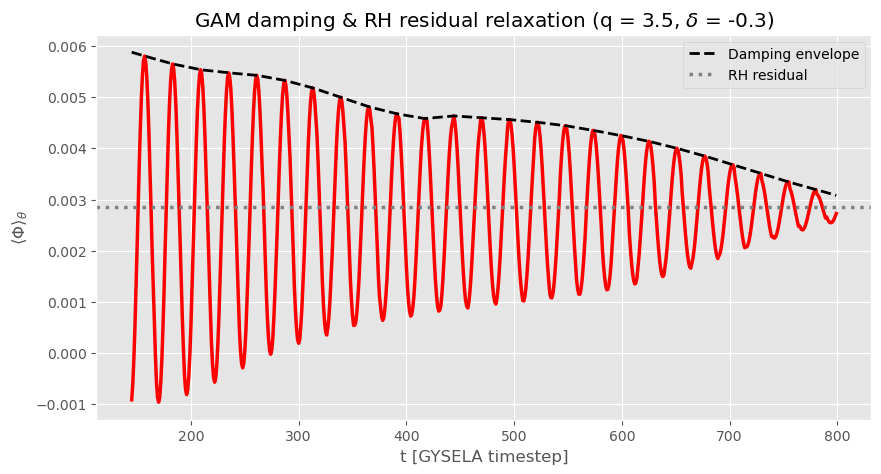

In [50]:

def plot_rosenbluth_hinton(phi2D_list, radial_index):
	# Signal isolation and data processing.
	time_series = utils.generate_poloidally_averaged_time_series(phi2D_list)[:, radial_index].values;
	time_range = np.arange(len(time_series));
	GAM_frequency = utils.extract_gam_frequency(phi2D_list, time_step, radial_index);
	amplitude_envelope, residual_level = utils.generate_residual_envelope(time_series, time_step, GAM_frequency);

	# Figure plotting logic.
	plt.figure(figsize = (10, 5));
	plt.plot(time_range[145:800], time_series[145:800], color = "red", lw = 2.5);
	plt.plot(time_range[145:800], amplitude_envelope[145:800], color = "black", linestyle = "--", label= "Damping envelope", lw = 2.0);
	plt.axhline(y = residual_level, color = "gray", linestyle = ":", label = f"RH residual", lw = 2.5);
	plt.xlabel("t [GYSELA timestep]");
	plt.ylabel(r"$\langle \Phi \rangle_\theta$");
	plt.title("GAM damping & RH residual relaxation (q = 3.5, $\delta$ = -0.3)");
	plt.legend(frameon = True, loc = "upper right");
	plt.show();

plot_rosenbluth_hinton(data_arrays, 180);